# Step 6 - Model Evaluation (V2)

## Purpose

This notebook evaluates the trained CNN on the corrected test split and measures how well it generalises to unseen vineyard images under the label definition used during training. The model was trained on folder-derived class labels because the dataset metadata (`Disease_Type`) conflicts systematically with the Healthy and Leaf Blight folders; this notebook therefore resolves each test image to its parent folder and uses that same `Target_Class` definition when calculating the V2 metrics.

The purpose of this evaluation is to validate the saved model with the same target logic used in training, quantify overall and per-class performance, and identify the error patterns that matter for real-world use. The original metadata label is retained only for traceability and comparison; it is not used as the ground truth in the corrected evaluation.


## Where to run this notebook

Run this notebook in the environment that contains all three required inputs:

1. this Git repository;
2. the complete GVLiD image folders; and
3. `cnn_v2_dropout040_best.keras` produced by Step 5.

Google Colab is recommended if the model and dataset are already stored in Google Drive. Mount Drive, clone or open the latest repository, and edit only the two optional path overrides in the configuration cell below. Evaluation does not require model retraining and can also run locally if TensorFlow, the images and the saved model are available.

In [1]:
from collections import defaultdict
from pathlib import Path
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

I0000 00:00:1789900510.092680   20040 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789900510.205585   20040 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789900513.959113   20040 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Configuration

The automatic project-root discovery works when the notebook is run from the repository root or its `notebooks` directory. In Colab, set `RAW_DATA_OVERRIDE` and `MODEL_PATH_OVERRIDE` if the large files are stored in Google Drive.

In [14]:
# Optional Colab setup (uncomment if needed):
# from google.colab import drive
# drive.mount('/content/drive')

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'processed' / 'dataset_split.csv').exists():
            return candidate
    raise FileNotFoundError(
        'Could not find the project root containing data/processed/dataset_split.csv.'
    )

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import RANDOM_SEED

# Set either value to a Path if Colab/Drive stores the files elsewhere.
RAW_DATA_OVERRIDE = None
MODEL_PATH_OVERRIDE = None
# Example:
# RAW_DATA_OVERRIDE = Path('/content/drive/MyDrive/grapevine/GVLiD')
# MODEL_PATH_OVERRIDE = Path('/content/drive/MyDrive/grapevine/cnn_v2_dropout040_best.keras')

default_raw_root = PROJECT_ROOT / 'data' / 'raw' / 'GVLiD'
if not default_raw_root.exists():
    default_raw_root = PROJECT_ROOT / 'data' / 'raw'

RAW_DATA_DIR = Path(RAW_DATA_OVERRIDE) if RAW_DATA_OVERRIDE else default_raw_root
MODEL_PATH = (
    Path(MODEL_PATH_OVERRIDE)
    if MODEL_PATH_OVERRIDE
    else PROJECT_ROOT / 'results' / 'cnn_v2_dropout040_best.keras'
)
SPLIT_FILE = PROJECT_ROOT / 'data' / 'processed' / 'dataset_split.csv'
HISTORY_PATH = PROJECT_ROOT / 'results' / 'cnn_v2_dropout040_training_history.pkl'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'evaluation_v2'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['Black Rot', 'Esca', 'Healthy', 'Leaf Blight']
LABEL_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}

CLASS_TO_FOLDER = {
    "Black Rot": "Black rot",
    "Esca": "esca",
    "Healthy": "healthy",
    "Leaf Blight": "leaf blight",
}
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('Project root:', PROJECT_ROOT)
print('Raw data:', RAW_DATA_DIR)
print('Model:', MODEL_PATH)
print('Split file:', SPLIT_FILE)

Project root: /home/chetan/Desktop/DL_Project/grapevine-disease-classification
Raw data: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/data/raw/GVLiD
Model: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/cnn_v2_dropout040_best.keras
Split file: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/data/processed/dataset_split.csv


In [15]:
required_paths = {
    'raw image directory': RAW_DATA_DIR,
    'trained model': MODEL_PATH,
    'split manifest': SPLIT_FILE,
}
missing_inputs = {name: path for name, path in required_paths.items() if not path.exists()}
if missing_inputs:
    details = '\n'.join(f'- {name}: {path}' for name, path in missing_inputs.items())
    raise FileNotFoundError(
        'Required evaluation inputs are missing. Correct the configuration paths before continuing:\n'
        + details
    )

print('All required inputs are available.')

All required inputs are available.


## Resolve images and reconstruct the modelling target

This is the key V2 correction. Image files are located recursively, and `Target_Class` is derived from the resolved image's class folder. `Disease_Type` remains in the table only so the disagreement can be audited.

In [16]:
required_columns = {"image_filename", "Vineyard", "Split", "Target_Class"}

split_df = pd.read_csv(SPLIT_FILE)
missing_columns = required_columns - set(split_df.columns)

if missing_columns:
    raise ValueError(f"Split manifest is missing columns: {sorted(missing_columns)}")

split_df["image_path"] = split_df.apply(
    lambda row: str(
        RAW_DATA_DIR / CLASS_TO_FOLDER[row["Target_Class"]] / row["image_filename"]
    ),
    axis=1,
)

split_df["label"] = split_df["Target_Class"].map(LABEL_TO_INDEX).astype(np.int32)

# Verify that all image paths exist
missing_images = split_df[~split_df["image_path"].map(Path).map(Path.exists)]

if not missing_images.empty:
    raise FileNotFoundError(
        f"{len(missing_images)} images could not be found. "
        f"Examples: {missing_images['image_filename'].head().tolist()}"
    )

print("Manifest rows:", len(split_df))
print("Resolved images:", split_df["image_path"].notna().sum())
print("Missing images:", len(missing_images))

display(pd.crosstab(split_df["Target_Class"], split_df["Split"]))

Manifest rows: 2407
Resolved images: 2407
Missing images: 0


Split,Test,Train,Validation
Target_Class,,,
Black Rot,15,68,14
Esca,133,620,133
Healthy,164,765,164
Leaf Blight,50,231,50


In [17]:
test_df = split_df[split_df['Split'].str.lower() == 'test'].copy().reset_index(drop=True)

if test_df.empty:
    raise ValueError('The split manifest contains no Test rows.')
if set(test_df['Target_Class']) != set(CLASS_NAMES):
    raise ValueError(
        'The test subset does not contain exactly the four expected target classes: '
        f'{sorted(test_df.Target_Class.unique())}'
    )

print('Test images:', len(test_df))
print('Corrected folder-derived test distribution:')
display(test_df['Target_Class'].value_counts().reindex(CLASS_NAMES).rename('support'))

Test images: 362
Corrected folder-derived test distribution:


Target_Class
Black Rot       15
Esca           133
Healthy        164
Leaf Blight     50
Name: support, dtype: int64

## Build the test pipeline

Only decoded, resized and normalised RGB pixels are passed to the CNN. Filenames, folder names and metadata are not model inputs. The test dataset is not shuffled so predictions remain aligned with `test_df`.

In [18]:
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

paths = test_df['image_path'].astype(str).to_numpy()
labels = test_df['label'].to_numpy(dtype=np.int32)
test_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
test_ds = test_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print('Test batches:', int(tf.data.experimental.cardinality(test_ds)))

Test batches: 12


## Load and validate the trained model

In [19]:
model = tf.keras.models.load_model(MODEL_PATH)
input_shape = tuple(model.input_shape[1:])
expected_input_shape = (*IMG_SIZE, 3)
if input_shape != expected_input_shape:
    raise ValueError(
        f'Model input shape is {input_shape}; expected {expected_input_shape} from Step 5.'
    )
output_units = int(model.output_shape[-1])
if output_units != len(CLASS_NAMES):
    raise ValueError(
        f'Model has {output_units} output units; expected {len(CLASS_NAMES)} for {CLASS_NAMES}.'
    )

print('Model loaded successfully.')
print('Model input shape:', input_shape)
print('Model output classes:', output_units)

Model loaded successfully.
Model input shape: (128, 128, 3)
Model output classes: 4


## Generate predictions using corrected test labels

In [20]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
y_prob = model.predict(test_ds, verbose=1)
y_true = labels
y_pred = np.argmax(y_prob, axis=1)

if len(y_pred) != len(test_df):
    raise RuntimeError('Prediction count does not match the test manifest.')
prediction_accuracy = accuracy_score(y_true, y_pred)
if not np.isclose(test_accuracy, prediction_accuracy, atol=1e-6):
    raise RuntimeError(
        f'model.evaluate accuracy ({test_accuracy}) does not match prediction accuracy '
        f'({prediction_accuracy}). Check test ordering and preprocessing.'
    )

print(f'Corrected test loss: {test_loss:.4f}')
print(f'Corrected test accuracy: {test_accuracy:.4f}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step - accuracy: 0.8204 - loss: 0.4188
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step
Corrected test loss: 0.4188
Corrected test accuracy: 0.8204


## Multiclass evaluation

Macro metrics give every class equal importance. The majority-class baseline is included so the CNN is not judged by accuracy in isolation.

In [21]:
accuracy = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
majority_baseline = test_df['Target_Class'].value_counts(normalize=True).max()

summary_df = pd.DataFrame({
    'Metric': [
        'Test loss', 'Test accuracy', 'Macro precision', 'Macro recall',
        'Macro F1', 'Weighted F1', 'Majority-class accuracy baseline'
    ],
    'Score': [
        test_loss, accuracy, macro_precision, macro_recall,
        macro_f1, weighted_f1, majority_baseline
    ],
})
display(summary_df.round(4))

report_dict = classification_report(
    y_true,
    y_pred,
    labels=range(len(CLASS_NAMES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.round(4))

,Metric,Score
0,Test loss,0.4188
1,Test accuracy,0.8204
2,Macro precision,0.6987
3,Macro recall,0.6702
4,Macro F1,0.6805
5,Weighted F1,0.8159
6,Majority-class accuracy baseline,0.4530


,precision,recall,f1-score,support
Black Rot,0.5385,0.4667,0.5000,15.0000
Esca,0.7564,0.8872,0.8166,133.0000
Healthy,0.9870,0.9268,0.9560,164.0000
Leaf Blight,0.5128,0.4000,0.4494,50.0000
accuracy,0.8204,0.8204,0.8204,0.8204
macro avg,0.6987,0.6702,0.6805,362.0000
weighted avg,0.8182,0.8204,0.8159,362.0000


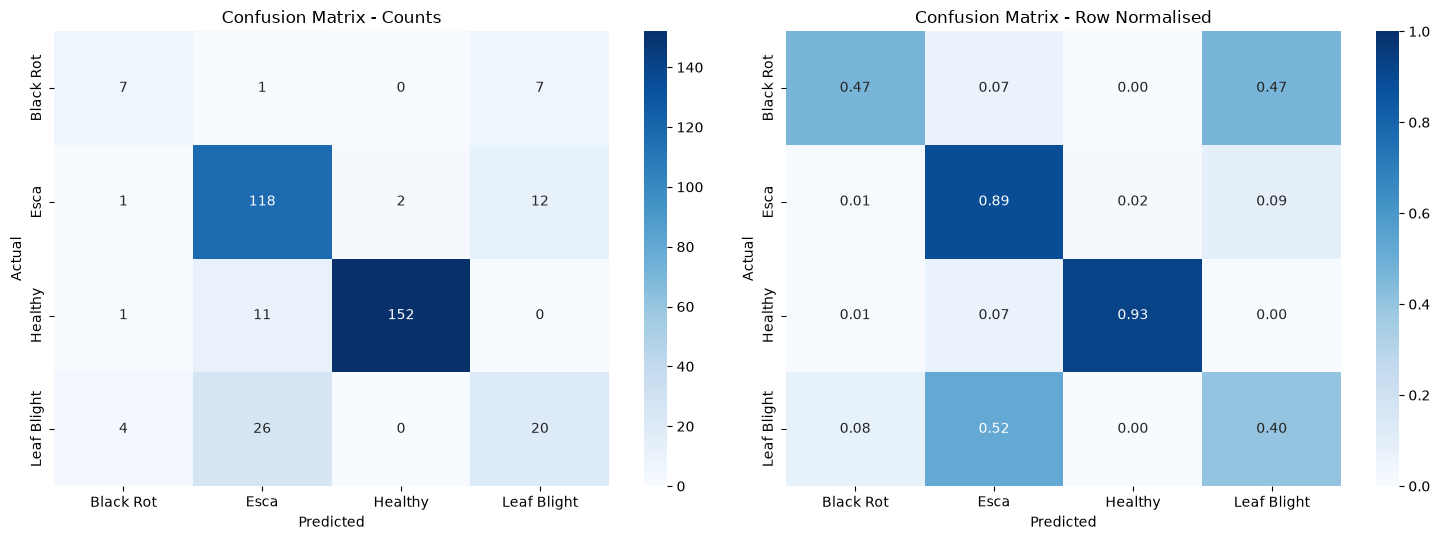

In [22]:
cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
cm_normalized = confusion_matrix(
    y_true, y_pred, labels=range(len(CLASS_NAMES)), normalize='true'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0]
)
axes[0].set(title='Confusion Matrix - Counts', xlabel='Predicted', ylabel='Actual')
sns.heatmap(
    cm_normalized, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1]
)
axes[1].set(title='Confusion Matrix - Row Normalised', xlabel='Predicted', ylabel='Actual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices_v2.png', dpi=300, bbox_inches='tight')
plt.show()

### Multiclass evaluation conclusion

The selected model achieved a test accuracy of 82.04%, a weighted F1-score of 81.59%, and a macro F1-score of 68.05%. Its accuracy substantially exceeds the 45.30% majority-class baseline, confirming that it learned useful visual patterns rather than relying only on the most frequent class.

However, the lower macro F1-score of 68.05% indicates that performance is uneven across the four classes and that overall accuracy is influenced by the larger Healthy and Esca classes.

Healthy produced the strongest performance, with 92.68% recall and an F1-score of 95.60%, followed by Esca with 88.72% recall and an F1-score of 81.66%. Performance was weaker for the minority classes: Black Rot achieved 46.67% recall and an F1-score of 50.00%, while Leaf Blight achieved 40.00% recall and an F1-score of 44.94%. These results should be interpreted cautiously because the test set contains only 15 Black Rot images and 50 Leaf Blight images.

The confusion matrices show that the main errors occur between disease classes. 7 of the 15 Black Rot images were predicted as Leaf Blight, while 26 of the 50 Leaf Blight images were predicted as Esca. In contrast, the model distinguished healthy leaves more reliably, correctly classifying 152 of 164 Healthy images.

Overall, the model shows good potential to prioritize which grapevines should be inspected, especially when distinguishing healthy leaves from diseased ones. However, its weaker discrimination between specific diseases means that it should not be used for autonomous diagnosis. Further development should prioritise additional expert-validated examples of Black Rot and Leaf Blight, class-level monitoring and evaluation using data collected in the intended Portuguese vineyard setting.

## Decision-support view: disease triage

The four-class metrics evaluate disease classification. For the proposed inspection-prioritisation use case, it is also useful to ask whether the model separates **any disease** from Healthy. Disease recall measures how many truly diseased test images would be flagged for review. This binary view supplements rather than replaces the four-class evaluation.

,Metric,Score
0,Disease precision,0.9423
1,Disease recall,0.9899
2,Disease F1,0.9655
3,Proportion flagged for review,0.5746


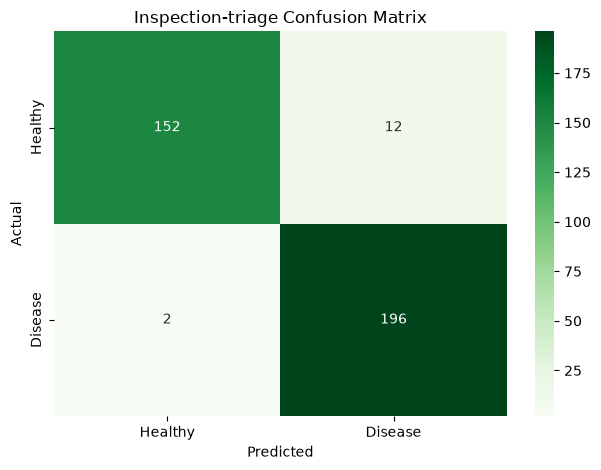

In [23]:
healthy_index = LABEL_TO_INDEX['Healthy']
y_true_disease = (y_true != healthy_index).astype(int)
y_pred_disease = (y_pred != healthy_index).astype(int)

triage_precision = precision_score(y_true_disease, y_pred_disease, zero_division=0)
triage_recall = recall_score(y_true_disease, y_pred_disease, zero_division=0)
triage_f1 = f1_score(y_true_disease, y_pred_disease, zero_division=0)
triage_cm = confusion_matrix(y_true_disease, y_pred_disease, labels=[0, 1])
review_rate = y_pred_disease.mean()

triage_df = pd.DataFrame({
    'Metric': ['Disease precision', 'Disease recall', 'Disease F1', 'Proportion flagged for review'],
    'Score': [triage_precision, triage_recall, triage_f1, review_rate],
})
display(triage_df.round(4))

sns.heatmap(
    triage_cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease']
)
plt.title('Inspection-triage Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'triage_confusion_matrix_v2.png', dpi=300, bbox_inches='tight')
plt.show()

### Decision-support conclusion

When the four classes are grouped into Healthy versus Disease, the model achieves 98.99% disease recall, 94.23% precision and an F1-score of 96.55%. It correctly flags 196 of 198 diseased images for review, missing only two, while 12 healthy images are unnecessarily flagged. Under this decision rule, 57.46% of the test images would be flagged for expert review.

These results support the proposed use of the model to prioritise grapevines for expert inspection. However, this analysis does not reveal the model's weaker ability to distinguish between specific diseases, so diagnosis and treatment decisions must remain with qualified experts.

## Four-class error analysis: high-confidence mistakes

Following the binary triage view, this section returns to the four-class predictions. The row-level table and image grid below retain traceability for the twelve mistakes with the highest model confidence. The quantitative summary then identifies recurring actual-to-predicted class pairs and counts errors with confidence of at least 80%. This 80% threshold is a descriptive review threshold for this analysis, not a calibrated guarantee of correctness.

Incorrect predictions: 65


,Image_ID,image_filename,Vineyard,Disease_Type,Target_Class,metadata_agrees_with_target,image_path,Predicted_Class,Confidence,Correct,Probability_Black Rot,Probability_Esca,Probability_Healthy,Probability_Leaf Blight
122,leaf blight089.jpg,leaf blight089.jpg,Vineyard_12,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Black Rot,0.890614,False,0.890614,0.003119,0.000017,0.106250
331,healthy877.jpg,healthy877.jpg,Vineyard_3,<NA>,Healthy,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Black Rot,0.887167,False,0.887167,0.008779,0.078379,0.025675
29,healthy643.jpg,healthy643.jpg,Vineyard_21,<NA>,Healthy,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.878387,False,0.000043,0.878387,0.024459,0.097112
324,leaf blight329.jpg,leaf blight329.jpg,Vineyard_19,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.856528,False,0.000167,0.856528,0.042023,0.101281
295,healthy570.jpg,healthy570.jpg,Vineyard_12,<NA>,Healthy,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.825349,False,0.000228,0.825349,0.004266,0.170156
241,leaf blight531.jpg,leaf blight531.jpg,Vineyard_24,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.821824,False,0.000088,0.821824,0.002746,0.175342
192,leaf blight481.jpg,leaf blight481.jpg,Vineyard_6,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.814014,False,0.000060,0.814014,0.000166,0.185760
233,healthy151.jpg,healthy151.jpg,Vineyard_13,<NA>,Healthy,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.797355,False,0.000007,0.797355,0.155836,0.046802
332,healthy906.jpg,healthy906.jpg,Vineyard_8,<NA>,Healthy,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.788891,False,0.000003,0.788891,0.175974,0.035133
291,leaf blight389.jpg,leaf blight389.jpg,Vineyard_11,<NA>,Leaf Blight,<NA>,/home/chetan/Desktop/DL_Project/grapevine-dise...,Esca,0.777727,False,0.001840,0.777727,0.022411,0.198022


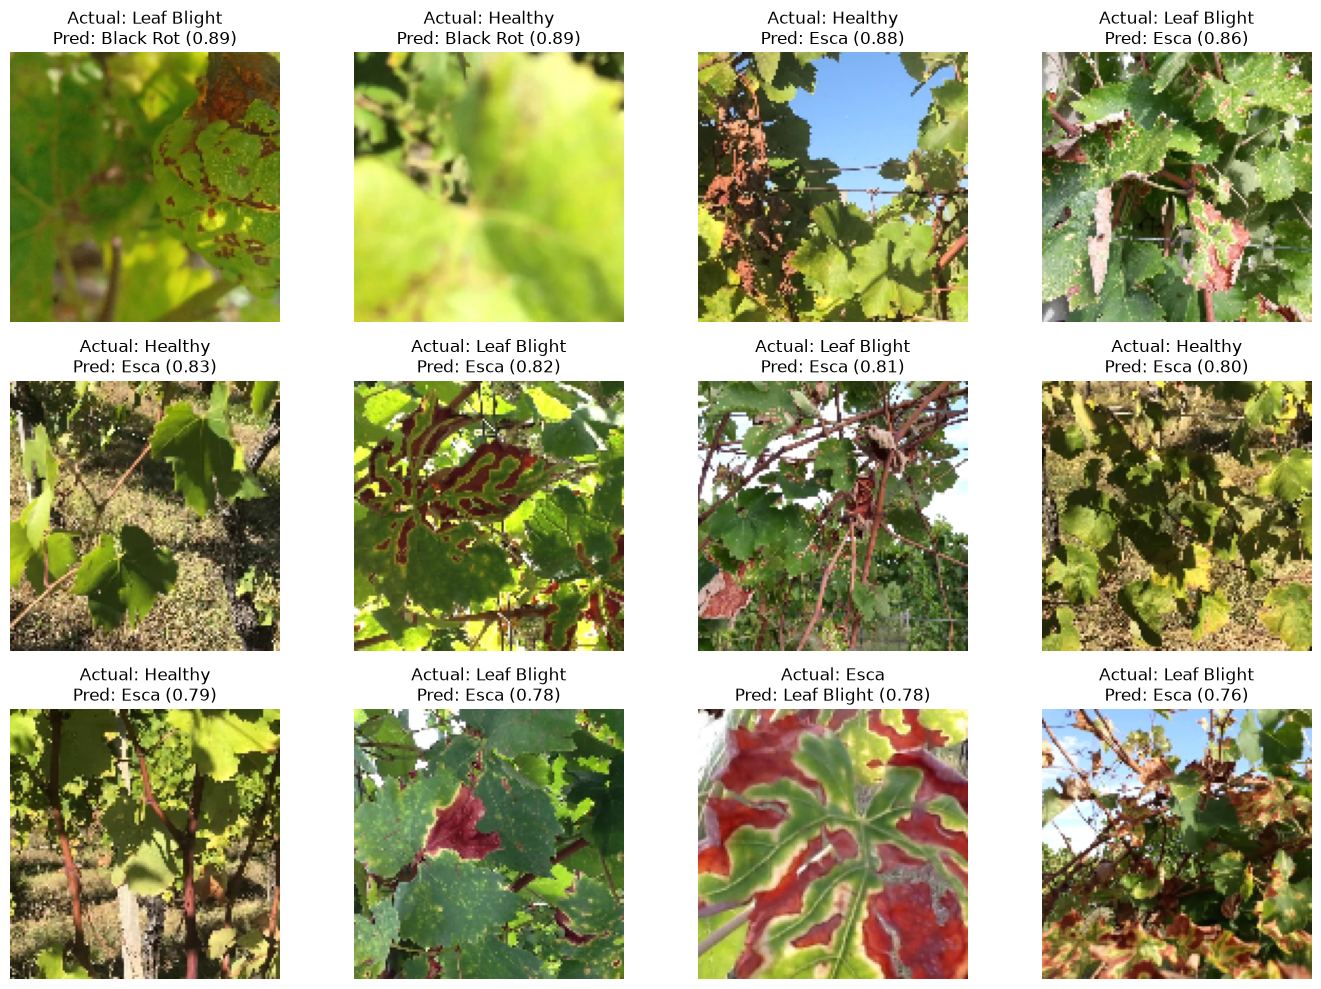

In [24]:
prediction_columns = [
    'Image_ID',
    'image_filename',
    'Vineyard',
    'Disease_Type',
    'Target_Class',
    'metadata_agrees_with_target',
    'image_path',
]

predictions_df = test_df.copy()

# Use available manifest columns and provide traceability fallbacks.
if 'Image_ID' not in predictions_df:
    predictions_df['Image_ID'] = predictions_df['image_filename']

for column in ['Disease_Type', 'metadata_agrees_with_target']:
    if column not in predictions_df:
        predictions_df[column] = pd.NA

predictions_df = predictions_df[prediction_columns].copy()
predictions_df['Predicted_Class'] = [CLASS_NAMES[i] for i in y_pred]
predictions_df['Confidence'] = y_prob.max(axis=1)
predictions_df['Correct'] = (y_true == y_pred)
for index, class_name in enumerate(CLASS_NAMES):
    predictions_df[f'Probability_{class_name}'] = y_prob[:, index]

errors_df = predictions_df[~predictions_df['Correct']].sort_values(
    'Confidence', ascending=False
)
print('Incorrect predictions:', len(errors_df))
display(errors_df.head(10))

sample_errors = errors_df.head(12)
if not sample_errors.empty:
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    for axis in axes.flat:
        axis.axis('off')
    for axis, (_, row) in zip(axes.flat, sample_errors.iterrows()):
        image = tf.keras.utils.load_img(row['image_path'], target_size=IMG_SIZE)
        axis.imshow(image)
        axis.set_title(
            f"Actual: {row['Target_Class']}\n"
            f"Pred: {row['Predicted_Class']} ({row['Confidence']:.2f})"
        )
        axis.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'high_confidence_errors_v2.png', dpi=300, bbox_inches='tight')
    plt.show()

### Quantitative error summary

This summary converts the row-level errors above into evidence that can be interpreted directly.

In [ ]:
error_summary = (
    errors_df
    .groupby(['Target_Class', 'Predicted_Class'], as_index=False)
    .agg(
        Error_Count=('image_filename', 'size'),
        Mean_Confidence=('Confidence', 'mean'),
        Maximum_Confidence=('Confidence', 'max'),
    )
    .sort_values(['Error_Count', 'Maximum_Confidence'], ascending=[False, False])
)
error_summary['Percentage_of_All_Errors'] = (
    100 * error_summary['Error_Count'] / len(errors_df)
).round(1)

print(f'Total incorrect predictions: {len(errors_df)}')
display(
    error_summary[[
        'Target_Class',
        'Predicted_Class',
        'Error_Count',
        'Percentage_of_All_Errors',
        'Mean_Confidence',
        'Maximum_Confidence',
    ]].round(3)
)

HIGH_CONFIDENCE_THRESHOLD = 0.80
high_confidence_errors = errors_df[
    errors_df['Confidence'] >= HIGH_CONFIDENCE_THRESHOLD
].copy()

print(
    f'Errors with confidence of at least {HIGH_CONFIDENCE_THRESHOLD:.0%}: ' 
    f'{len(high_confidence_errors)}'
)
display(
    high_confidence_errors[[
        'image_filename',
        'Target_Class',
        'Predicted_Class',
        'Confidence',
    ]].round({'Confidence': 3})
)

### Error-analysis conclusion

The model made 65 incorrect predictions. The most frequent error was Leaf Blight predicted as Esca, accounting for 26 errors (40.0% of all errors). Other frequent patterns were Esca predicted as Leaf Blight (12 errors), Healthy predicted as Esca (11 errors), and Black Rot predicted as Leaf Blight (7 errors). Together, these four patterns account for 56 of the 65 errors.

Seven incorrect predictions had confidence of at least 80%: three Leaf Blight images predicted as Esca, two Healthy images predicted as Esca, one Leaf Blight image predicted as Black Rot, and one Healthy image predicted as Black Rot. This demonstrates that high softmax confidence does not guarantee a correct classification.

The errors are concentrated in a small number of class pairs, particularly among the disease classes. This reinforces the proposed expert-in-the-loop use case: the model may help prioritise images for inspection, but it should not make autonomous disease diagnoses or treatment decisions.

## Training history of the selected model

These curves show how the selected dropout-0.40 model performed during training and validation. They are used to understand model fitting and model selection, while final performance is assessed using the held-out test metrics reported above.

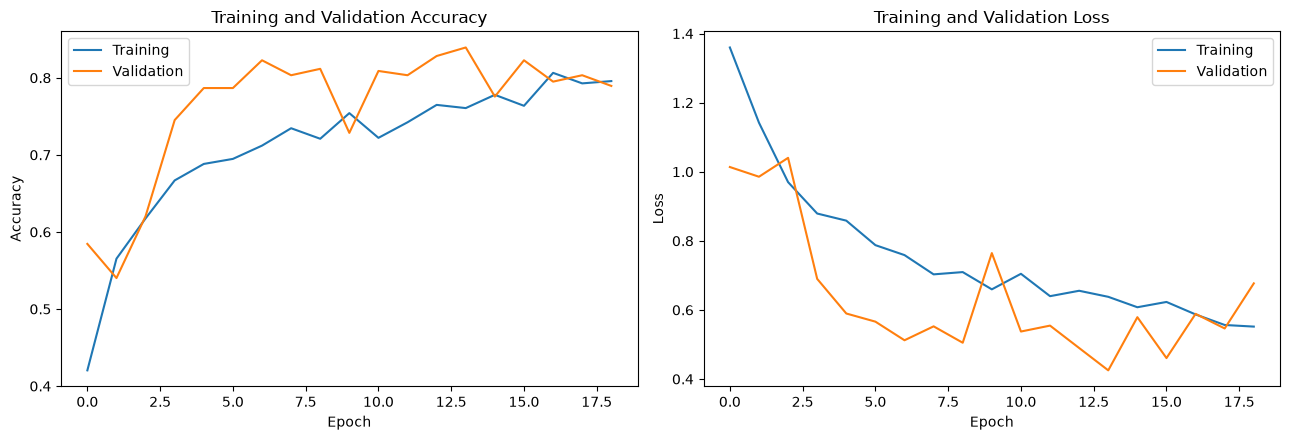

In [25]:
if HISTORY_PATH.exists():
    with open(HISTORY_PATH, 'rb') as file:
        history = pickle.load(file)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history['accuracy'], label='Training')
    axes[0].plot(history['val_accuracy'], label='Validation')
    axes[0].set(title='Training and Validation Accuracy', xlabel='Epoch', ylabel='Accuracy')
    axes[0].legend()
    axes[1].plot(history['loss'], label='Training')
    axes[1].plot(history['val_loss'], label='Validation')
    axes[1].set(title='Training and Validation Loss', xlabel='Epoch', ylabel='Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_history_v2.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Training history not found; skipping curves:', HISTORY_PATH)

Training accuracy improved progressively while training loss decreased. Validation performance improved overall but fluctuated between epochs, reaching its lowest validation loss at epoch 14. The subsequent increase in validation loss suggests some late-stage instability or overfitting. Early stopping therefore restored the weights from the best epoch, which are the weights used for the final test evaluation.

## Save corrected results

V2 outputs use separate filenames and do not overwrite the original, invalid evaluation results.

In [26]:
summary_df.to_csv(OUTPUT_DIR / 'summary_metrics_v2.csv', index=False)
report_df.to_csv(OUTPUT_DIR / 'classification_report_v2.csv')
triage_df.to_csv(OUTPUT_DIR / 'triage_metrics_v2.csv', index=False)
predictions_df.drop(columns=['image_path']).to_csv(
    OUTPUT_DIR / 'test_predictions_v2.csv', index=False
)
pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    OUTPUT_DIR / 'confusion_matrix_counts_v2.csv'
)

print('Corrected evaluation outputs saved to:', OUTPUT_DIR)

Corrected evaluation outputs saved to: /home/chetan/Desktop/DL_Project/grapevine-disease-classification/results/evaluation_v2


## Final evaluation findings

The corrected test set shows 82.0% accuracy and a macro F1 of 0.68. Performance is strong for Healthy and Esca, with F1 scores of 0.96 and 0.82 respectively, but substantially weaker for Black Rot and Leaf Blight at 0.50 and 0.45. The model therefore separates healthy leaves from diseased leaves much more reliably than it distinguishes among the four disease classes.

This supports a limited triage role for prioritising likely abnormal vines for expert inspection, but the evidence does not support using the current model as a stand-alone disease diagnosis system. The practical use is to flag cases for human review rather than to make final disease decisions without agronomic confirmation.


## Limitations
The main limitation is the dataset and label ambiguity: the folder-derived target was used as a provisional ground truth because metadata and folder labels conflict systematically. Class imbalance and symptom overlap also reduce performance for some disease types, especially Leaf Blight, while overfitting risk remains possible given the limited scope of the study. As a result, the model is not yet reliable for exact disease naming in production.

## Proposed Next Pilots
Next steps should focus on improving decision quality before operational use: balance the dataset, collect more diverse vineyard images, and test augmentation plus transfer learning to improve minority-class recall. A practical pilot would add confidence thresholds and a human-review workflow so only borderline cases require agronomist input. If triage performance remains stable across new farms, the model can move from research pilot to a monitored decision-support tool.

## Final conclusions

The corrected evaluation indicates that the model is viable as a vineyard triage aid, but not yet for final disease diagnosis. It achieves a clear improvement over the majority-class baseline and performs best on Healthy and Esca, while Black Rot and Leaf Blight remain substantially under-detected. The current evidence supports limited pilot use for prioritising human review, with expert validation and additional data collection required before any operational deployment.
